In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df1 = pd.read_csv("/home/mengelsl/MA-bench-framework/eigen/outputs/perf_20260105_114807/perf_results.csv")
df1 = df1.groupby(['n_cores', 'matrix_path', 'algorithm']).median(numeric_only=True).reset_index()

In [20]:
#calculate speedup compared to 1 core
df1['speedup'] = df1.apply(lambda row: df1[(df1['n_cores'] == 1) & (df1['algorithm'] == row['algorithm'])]['perf_walltime_ns'].values[0] / row['perf_walltime_ns'], axis=1)


<Axes: xlabel='n_cores', ylabel='perf_cache_misses'>

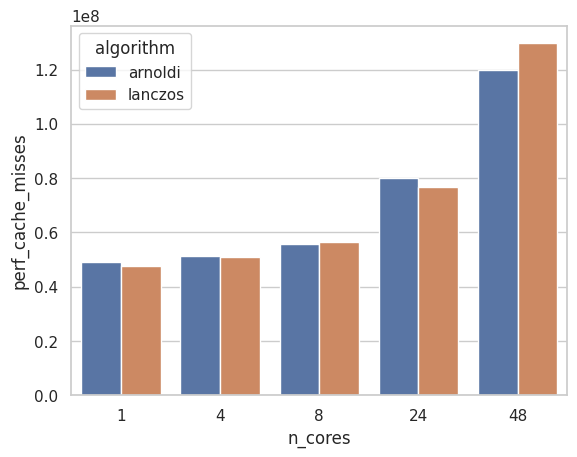

In [23]:
sns.barplot(data=df1, x='n_cores', y='perf_cache_misses', hue='algorithm')